# Plan-and-Execute

이 튜토리얼에서는 "plan-and-execute" 스타일의 에이전트를 만드는 방법을 소개하고, 이를 [LangGraph](https://langchain-ai.github.io/langgraph/)를 활용하여 구현하는 과정을 단계별로 설명합니다.  
"plan-and-execute" 전략은 복잡한 작업을 수행할 때 장기적인 계획을 먼저 수립한 뒤, 해당 계획을 단계별로 실행하며 필요에 따라 다시 계획을 재수정하는 접근법입니다.

![](./assets/langgraph-plan-and-execute.png)

---

## Plan-and-Execute란 무엇인가?

"plan-and-execute"는 다음과 같은 특징을 갖는 접근 방식입니다.

- **장기 계획 수립**: 복잡한 작업을 수행하기 전에 큰 그림을 그리는 장기 계획을 수립합니다.
- **단계별 실행 및 재계획**: 세운 계획을 단계별로 실행하고, 각 단계가 완료될 때마다 계획이 여전히 유효한지 검토한 뒤 수정할 수 있습니다.
  
이 방식은 [Plan-and-Solve 논문](https://arxiv.org/abs/2305.04091)과 [Baby-AGI 프로젝트](https://github.com/yoheinakajima/babyagi)에서 영감을 받았습니다. 전통적인 [ReAct 스타일](https://arxiv.org/abs/2210.03629)의 에이전트는 한 번에 한 단계씩 생각하는 반면, "plan-and-execute"는 명시적이고 장기적인 계획을 강조합니다.

**장점**:
1. **명시적인 장기 계획**: 강력한 LLM조차도 한 번에 장기 계획을 처리하는 데 어려움을 겪을 수 있습니다. 명시적으로 장기 계획을 수립함으로써, 보다 안정적인 진행이 가능합니다.
2. **효율적인 모델 사용**: 계획 단계에서는 더 큰/강력한 모델을 사용하고, 실행 단계에서는 상대적으로 작은/약한 모델을 사용함으로써 자원 소비를 최적화할 수 있습니다.

---

**주요 내용**

- **도구 정의**: 사용할 도구 정의
- **실행 에이전트 정의**: 실제 작업을 실행하는 에이전트 생성
- **상태 정의**: 에이전트의 상태 정의
- **계획 단계**: 장기 계획을 세우는 단계 생성
- **재계획 단계**: 작업 진행 상황에 따라 계획을 재수정하는 단계 생성
- **그래프 생성 및 실행**: 이러한 단계들을 연결하는 그래프 생성 및 실행

---

**참고**

- [LangGraph 공식 문서](https://langchain-ai.github.io/langgraph/)  
- [Plan-and-Solve 논문](https://arxiv.org/abs/2305.04091)  
- [Baby-AGI 프로젝트](https://github.com/yoheinakajima/babyagi)  
- [ReAct 논문](https://arxiv.org/abs/2210.03629)

지금부터는 각 단계를 따라가며 "plan-and-execute" 에이전트를 LangGraph로 구현하는 방법을 자세히 알아보겠습니다.

## 환경 설정

Plan-and-Execute 에이전트를 구현하기 위해 필요한 환경을 설정합니다. API 키를 환경변수로 관리하고, LangSmith를 통해 실행 과정을 추적할 수 있도록 설정합니다.

아래 코드는 `.env` 파일에서 API 키를 로드하고 LangSmith 추적을 활성화합니다.

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적을 설정합니다.
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangGraph-Use-Cases")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-Use-Cases


실습에 활용할 모델을 정의합니다. Plan-and-Execute 패턴의 핵심 장점 중 하나는 **계획 단계와 실행 단계에 서로 다른 모델을 사용**할 수 있다는 점입니다.

- `PLANNER_MODEL`: 계획 수립 및 재계획에 사용하는 모델 (추론 능력이 중요)
- `EXECUTOR_MODEL`: 실제 작업 실행에 사용하는 모델 (도구 호출 및 빠른 응답이 중요)

이렇게 분리하면 비용을 최적화하고, 서로 다른 API 제공자의 Rate Limit을 분산할 수 있습니다.

In [3]:
from langchain.chat_models import init_chat_model

# 계획(Plan) 및 재계획(Re-Plan) 단계에서 사용할 모델
PLANNER_MODEL = "claude-sonnet-4-5"

# 실행(Execute) 단계에서 사용할 모델
EXECUTOR_MODEL = "claude-haiku-4-5"

print(f"Planner Model: {PLANNER_MODEL}")
print(f"Executor Model: {EXECUTOR_MODEL}")

Planner Model: claude-sonnet-4-5
Executor Model: claude-haiku-4-5


## 도구 정의

사용할 도구를 먼저 정의합니다. 이 간단한 예제에서는 `Tavily`를 통해 제공되는 내장 검색 도구를 사용할 것입니다. 그러나 직접 도구를 만드는 것도 매우 쉽습니다. 

자세한 내용은 [도구(Tools)](https://wikidocs.net/262582) 문서를 참조하십시오.

In [4]:
from langchain_teddynote.tools import TavilySearch

# Tavily 검색 도구 초기화
tools = [TavilySearch(max_results=1)]

## 작업 실행 에이전트 정의

이제 작업을 실행할 `execution agent`를 생성합니다. 이 예제에서는 각 작업에 동일한 `execution agent`를 사용하지만, 필요에 따라 작업별로 다른 에이전트를 사용할 수 있습니다.

`create_agent` 함수는 LangChain의 agents 모듈에서 제공되며, ReAct(Reasoning + Acting) 패턴을 구현한 에이전트를 생성합니다. 이 에이전트는 도구를 사용하여 정보를 수집하고 추론을 수행합니다.

아래 코드는 Tavily 검색 도구를 사용하는 ReAct 에이전트를 생성합니다.

In [5]:
from langchain.agents import create_agent

# 시스템 프롬프트 정의
system_prompt = "You are a helpful assistant. Answer in Korean."

# ReAct 에이전트 생성 (실행 단계에서는 가벼운 모델 사용)
# system_prompt를 사용하여 시스템 프롬프트를 설정합니다.
agent_executor = create_agent(
    init_chat_model(EXECUTOR_MODEL, temperature=0),
    tools,
    system_prompt=system_prompt,
)

In [6]:
# 에이전트 실행
agent_executor.invoke(
    {"messages": [("user", "랭체인 한국어 튜토리얼에 대해서 설명해줘")]}
)

{'messages': [HumanMessage(content='랭체인 한국어 튜토리얼에 대해서 설명해줘', additional_kwargs={}, response_metadata={}, id='828fb3d5-30e5-4cc5-a909-974f18ee90af'),
  AIMessage(content=[{'text': '랭체인(LangChain)의 한국어 튜토리얼에 대해 최신 정보를 찾아드리겠습니다.', 'type': 'text'}, {'id': 'toolu_01KYZeAM7FZy86VfovRSPXnP', 'input': {'query': '랭체인 LangChain 한국어 튜토리얼'}, 'name': 'tavily_web_search', 'type': 'tool_use', 'caller': {'type': 'direct'}}, {'id': 'toolu_01Ezg5QBgAS3bcnSraoXEarY', 'input': {'query': 'LangChain 한국어 가이드 설명'}, 'name': 'tavily_web_search', 'type': 'tool_use', 'caller': {'type': 'direct'}}], additional_kwargs={}, response_metadata={'id': 'msg_01Q14jxC4GccbcpN3fFYpNLb', 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'input_tokens': 665, 'output_tokens': 175, 'server_tool_use': None, 'service_tier': 'standard', '

## 상태 정의

- `input`: 사용자의 입력
- `plan`: 현재 계획
- `past_steps`: 이전에 실행한 계획과 실행 결과
- `response`: 최종 응답

In [ ]:
import operator
from typing import Annotated, List, Tuple
from typing_extensions import TypedDict


# 상태 정의
class PlanExecute(TypedDict):
    input: Annotated[str, "사용자의 입력"]
    plan: Annotated[List[str], "현재 계획"]
    past_steps: Annotated[List[Tuple], operator.add]
    response: Annotated[str, "최종 응답"]

## 계획(Plan) 단계

이제 **계획 단계**를 생성합니다. 이 단계에서는 `function calling`(도구 호출)을 사용하여 구조화된 계획을 수립합니다.

LLM에 `with_structured_output` 메서드를 사용하여 Pydantic 모델 형식으로 출력을 강제합니다. 이를 통해 계획이 항상 일관된 형식으로 생성됩니다.

아래 코드는 Plan 모델과 planner 체인을 정의합니다.

In [ ]:
from pydantic import BaseModel, Field
from typing import List


# Plan 모델 정의
class Plan(BaseModel):
    """계획을 실행하기 위한 정렬된 단계 목록"""

    steps: Annotated[List[str], "실행할 단계 목록 (순서대로 정렬)"]

In [9]:
from langchain_core.prompts import ChatPromptTemplate

# 계획 수립을 위한 프롬프트 템플릿 생성
planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """For the given objective, come up with a simple step by step plan. \
This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. \
The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.
Prefer fewer, broader steps over many narrow ones. Combine closely related tasks into a single step.
Scale the number of steps to the complexity of the objective - simple questions need only 1-2 steps, while complex questions may need more.
Answer in Korean.""",
        ),
        ("placeholder", "{messages}"),
    ]
)

# 계획 단계에서는 추론 능력이 뛰어난 모델 사용
planner = planner_prompt | init_chat_model(
    PLANNER_MODEL, temperature=0
).with_structured_output(Plan)

`planner`를 실행하여 계획을 수립한 결과를 확인합니다. 사용자의 질문에 대해 단계별 계획이 생성됩니다.

In [10]:
# Planner 실행
planner.invoke(
    {
        "messages": [
            (
                "user",
                """Slot Filling

사용자 질문의 의도를 정확하게 파악하고 답변을 하기 위해서는 꼭 필요한 정보들이 있을텐데, 해당 entity를 어떻게 확보해서 답변을 할 수 있을지 고민이 있습니다.  
예를들면 회의실을 예약하는 시나리오라고 하면, 시간, 장소, 인원 등의 필수 정보가 있어야할텐데 이런 항목을 multi-turn 활용하여 채울 수 있는 방법이 있겠으나  
범용적으로 사용하기에는 도메인별로 필요한 Entity가 달라서 어떻게 하면 좋을지 고민 입니다.  
외부에서 Slot Filling 방식으로 활용하고 있는지, 어떻게 활용하는지 알고 싶습니다.  """,
            )
        ]
    }
)

Plan(steps=['Slot Filling의 개념과 필요성을 설명하고, 회의실 예약 시나리오를 예시로 필수 정보(시간, 장소, 인원) 수집의 중요성 정리', '범용적인 Slot Filling 구현 방법론 제시: 1) 도메인별 스키마 정의 방식 2) LLM 기반 동적 슬롯 추출 방식 3) 하이브리드 접근법', '실제 산업에서 활용되는 Slot Filling 사례 소개: 대화형 AI 어시스턴트(Google Dialogflow, Amazon Lex), 챗봇 플랫폼, 음성 비서(Alexa, Siri) 등의 구현 방식', 'Multi-turn 대화를 통한 슬롯 채우기 전략 제시: 1) 누락된 슬롯 우선순위 지정 2) 자연스러운 질문 생성 3) 컨텍스트 유지 4) 확인 및 수정 메커니즘', '도메인 확장성을 위한 실용적 솔루션 제안: 1) 설정 파일 기반 슬롯 정의 2) Few-shot learning 활용 3) 슬롯 검증 로직 분리 4) 템플릿 기반 대화 관리'])

## 재계획(Re-Plan) 단계

이제 이전 단계의 결과를 바탕으로 계획을 다시 수립하는 단계를 생성합니다. 재계획 단계에서는 현재까지 완료된 작업을 검토하고, 남은 작업을 업데이트합니다.

`Act` 모델은 두 가지 유형의 행동을 정의합니다:
- **Response**: 사용자에게 최종 응답을 제공할 때 사용
- **Plan**: 추가 도구 사용이 필요할 때 사용

아래 코드는 재계획을 위한 프롬프트와 replanner 체인을 정의합니다.

In [ ]:
from typing import Union


class Response(BaseModel):
    """사용자에게 전달할 응답"""

    # 사용자 응답
    response: str


class Act(BaseModel):
    """수행할 작업"""

    # 수행할 작업: "Response", "Plan". 사용자에게 응답할 경우 Response 사용, 추가 도구 사용이 필요할 경우 Plan 사용
    action: Union[Response, Plan] = Field(
        description="Action to perform. If you want to respond to user, use Response. "
        "If you need to further use tools to get the answer, use Plan."
    )


# 계획을 재수립하기 위한 프롬프트 정의
replanner_prompt = ChatPromptTemplate.from_template(
    """You are a replanner. Review the completed steps and determine what to do next.

Your objective was this:
{input}

Your original plan was this:
{plan}

You have currently done the follow steps:
{past_steps}

IMPORTANT RULES:
1. Carefully review the ANSWERS from the completed steps. If they already contain enough information to fully answer the objective, respond with Response immediately.
2. Only return steps that still NEED to be done and are NOT already covered by the completed steps' answers.
3. Do NOT split or expand remaining steps into smaller sub-steps. Keep the same granularity as the original plan.
4. The number of remaining steps must NEVER exceed the number of unfinished steps in the original plan.

If no more steps are needed, respond with Response that synthesizes the completed steps into a final answer.

Answer in Korean."""
)


# 재계획 단계에서도 추론 능력이 뛰어난 모델 사용
replanner = replanner_prompt | init_chat_model(
    PLANNER_MODEL, temperature=0
).with_structured_output(Act)

## 그래프 생성

이제 Plan-and-Execute 워크플로우를 구현하는 그래프를 생성합니다. 그래프는 다음과 같은 노드로 구성됩니다:

- **planner**: 초기 계획을 수립하는 노드
- **execute**: 계획의 각 단계를 실행하는 노드
- **replan**: 실행 결과를 바탕으로 재계획하는 노드
- **final_report**: 최종 보고서를 생성하는 노드

아래 코드는 각 노드의 함수와 최종 보고서 생성 로직을 정의합니다.

In [12]:
from langchain_core.output_parsers import StrOutputParser
from datetime import datetime


# 사용자 입력을 기반으로 계획을 생성하고 반환
def plan_step(state: PlanExecute):
    plan = planner.invoke({"messages": [("user", state["input"])]})
    # 생성된 계획의 단계 리스트 반환
    return {"plan": plan.steps}


# 에이전트 실행기를 사용하여 주어진 작업을 수행하고 결과를 반환
def execute_step(state: PlanExecute):
    plan = state["plan"]
    # 계획을 문자열로 변환하여 각 단계에 번호를 매김
    plan_str = "\n".join(f"{i+1}. {step}" for i, step in enumerate(plan))
    task = plan[0]
    # 현재 실행할 작업을 포맷팅하여 에이전트에 전달
    task_formatted = f"""For the following plan:
{plan_str}\n\nYou are tasked with executing [step 1. {task}]."""
    # 에이전트 실행기를 통해 작업 수행 및 결과 수신
    agent_response = agent_executor.invoke({"messages": [("user", task_formatted)]})
    # 이전 단계와 그 결과를 포함하는 딕셔너리 반환
    return {
        "past_steps": [(task, agent_response["messages"][-1].content)],
    }


# 이전 단계의 결과를 바탕으로 계획을 업데이트하거나 최종 응답을 반환
def replan_step(state: PlanExecute):
    output = replanner.invoke(state)
    # 응답이 사용자에게 반환될 경우
    if isinstance(output.action, Response):
        return {"response": output.action.response}
    # 추가 단계가 필요할 경우 계획의 단계 리스트 반환
    else:
        next_plan = output.action.steps
        if len(next_plan) == 0:
            return {"response": "No more steps needed."}
        else:
            return {"plan": next_plan}


# 에이전트의 실행 종료 여부를 결정하는 함수
def should_end(state: PlanExecute):
    if "response" in state and state["response"]:
        return "final_report"
    else:
        return "execute"


final_report_prompt = ChatPromptTemplate.from_template(
    """You are given the objective and the previously done steps. Your task is to generate a final report in markdown format.
Final report should be written in professional tone.
Today's date is {today}.

Your objective was this:

{input}

Your previously done steps(question and answer pairs):

{past_steps}

Generate a final report in markdown format. Write your response in Korean."""
)

# 최종 보고서 생성에는 추론 능력이 뛰어난 모델 사용
final_report = (
    final_report_prompt
    | init_chat_model(PLANNER_MODEL, temperature=0)
    | StrOutputParser()
)


def generate_final_report(state: PlanExecute):
    past_steps = "\n\n".join(
        [
            f"Question: {past_step[0]}\n\nAnswer: {past_step[1]}\n\n####"
            for past_step in state["past_steps"]
        ]
    )
    # 현재 날짜를 주입하여 최종 보고서 생성
    response = final_report.invoke(
        {
            "input": state["input"],
            "past_steps": past_steps,
            "today": datetime.today().strftime("%Y-%m-%d"),
        }
    )
    return {"response": response}

### 그래프 조립

이제 지금까지 정의한 노드를 연결하여 그래프를 생성합니다. `add_conditional_edges`를 사용하여 `replan` 노드 이후의 분기를 처리합니다.

`MemorySaver`를 사용하여 그래프 실행 상태를 저장하고, 이후에 상태를 복원할 수 있습니다. 아래 코드는 StateGraph를 조립하고 컴파일합니다.

In [13]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver


# 그래프 생성
workflow = StateGraph(PlanExecute)

# 노드 정의
workflow.add_node("planner", plan_step)
workflow.add_node("execute", execute_step)
workflow.add_node("replan", replan_step)
workflow.add_node("final_report", generate_final_report)

# 엣지 정의
workflow.add_edge(START, "planner")
workflow.add_edge("planner", "execute")
workflow.add_edge("execute", "replan")
workflow.add_edge("final_report", END)

# 조건부 엣지: replan 후 종료 여부를 결정하는 함수 사용
workflow.add_conditional_edges(
    "replan",
    should_end,
    {"execute": "execute", "final_report": "final_report"},
)

# 그래프 컴파일
app = workflow.compile(checkpointer=MemorySaver())

그래프를 시각화하여 노드 간의 연결 관계를 확인합니다. `xray=True` 옵션을 사용하면 내부 구조를 더 자세히 볼 수 있습니다.

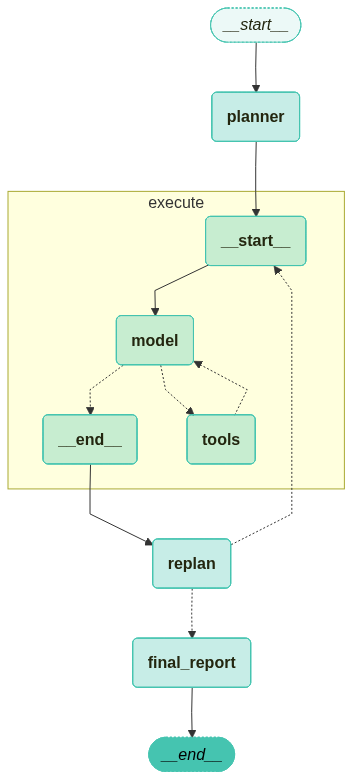

In [14]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(app, xray=True)

## 그래프 실행

이제 생성한 Plan-and-Execute 에이전트를 실행합니다. `invoke_graph` 함수를 사용하여 그래프를 실행하고 결과를 확인합니다.

`recursion_limit`을 설정하여 무한 루프를 방지하고, `thread_id`를 통해 세션을 구분합니다. 아래 코드는 AI Agent와 워크플로우의 차이점에 대한 질문을 처리합니다.

In [15]:
from langchain_teddynote.messages import invoke_graph, random_uuid
from langchain_core.runnables import RunnableConfig

config = RunnableConfig(recursion_limit=50, configurable={"thread_id": random_uuid()})

inputs = {
    "input": """AI Agent 와 워크플로우의 차이에 대해서 설명하고, 각각의 장단점에 대해서 설명하세요"""
}

invoke_graph(app, inputs, config)


🔄 Node: planner 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
AI Agent와 워크플로우의 정의 및 핵심 차이점 설명 - AI Agent는 자율적으로 의사결정하고 동적으로 작업을 수행하는 시스템이며, 워크플로우는 미리 정의된 순서대로 작업을 실행하는 구조화된 프로세스임을 명확히 구분
AI Agent의 장단점 분석 - 장점(유연성, 자율성, 복잡한 문제 해결 능력, 학습 및 적응 능력, 예외 상황 처리)과 단점(예측 불가능성, 높은 비용, 디버깅 어려움, 제어의 어려움, 일관성 부족) 설명
워크플로우의 장단점 분석 - 장점(예측 가능성, 일관성, 명확한 제어, 디버깅 용이, 비용 효율성)과 단점(유연성 부족, 예외 처리 한계, 복잡한 의사결정 불가, 수동 업데이트 필요) 설명
사용 사례 및 선택 기준 제시 - 각각이 적합한 상황과 실무에서의 활용 방안 요약

🔄 Node: model in [execute] 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================

# AI Agent와 워크플로우의 정의 및 핵심 차이점

## 1. AI Agent의 정의

**AI Agent(인공지능 에이전트)**는 환경을 인식하고 자율적으로 의사결정을 내려 동적으로 작업을 수행하는 지능형 시스템입니다.

### 주요 특징:
- **자율성(Autonomy)**: 사전 프로그래밍 없이 상황에 따라 독립적으로 행동
- **동적 의사결정**: 실시간 데이터와 상황 변화에 따라 전략을 조정
- **학습 능력**: 과거 경험으로부터 학습하여 성능 개선
- **목표 지향성**: 주어진 목표를 달성하기 위해 최적의 경로 선택
- **상황 인식**: 환경의 변화를 감지하고 대응

**예시**: 챗봇, 자율주행 자동차, 추천 시스템, 자동 거래 시스템


In [ ]:
from IPython.display import Markdown

# 그래프 상태 값 가져오기
snapshot = app.get_state(config).values

Markdown(snapshot["response"])

# AI Agent와 워크플로우 비교 분석 보고서

**작성일**: 2026년 2월 28일

---

## 목차

1. [개요](#1-개요)
2. [AI Agent와 워크플로우의 정의](#2-ai-agent와-워크플로우의-정의)
3. [핵심 차이점 분석](#3-핵심-차이점-분석)
4. [AI Agent의 장단점](#4-ai-agent의-장단점)
5. [워크플로우의 장단점](#5-워크플로우의-장단점)
6. [비교 분석 및 선택 가이드](#6-비교-분석-및-선택-가이드)
7. [결론 및 권고사항](#7-결론-및-권고사항)

---

## 1. 개요

본 보고서는 AI Agent와 워크플로우의 개념적 차이를 명확히 하고, 각각의 장단점을 체계적으로 분석하여 실무 적용 시 최적의 선택을 할 수 있도록 가이드를 제공합니다. 디지털 전환 시대에 두 접근 방식에 대한 정확한 이해는 조직의 자동화 전략 수립에 필수적입니다.

---

## 2. AI Agent와 워크플로우의 정의

### 2.1 AI Agent

**AI Agent(인공지능 에이전트)**는 환경을 인식하고 자율적으로 의사결정을 내려 동적으로 작업을 수행하는 지능형 시스템입니다.

**핵심 특징:**
- **자율성(Autonomy)**: 사전 프로그래밍 없이 상황에 따라 독립적으로 행동
- **동적 의사결정**: 실시간 데이터와 상황 변화에 따라 전략을 조정
- **학습 능력**: 과거 경험으로부터 학습하여 성능 개선
- **목표 지향성**: 주어진 목표를 달성하기 위해 최적의 경로 선택
- **상황 인식**: 환경의 변화를 감지하고 대응

**대표적 활용 사례:**
- 지능형 챗봇 및 가상 비서
- 자율주행 자동차
- 개인화 추천 시스템
- 자동 거래 시스템

### 2.2 워크플로우

**워크플로우(Workflow)**는 미리 정의된 규칙과 순서에 따라 작업을 자동으로 실행하는 구조화된 프로세스입니다.

**핵심 특징:**
- **사전 정의성**: 모든 단계와 조건이 미리 설정됨
- **순차적 실행**: 정해진 순서대로 작업 진행
- **규칙 기반**: 명확한 if-then 규칙에 따라 동작
- **예측 가능성**: 동일한 입력에 대해 항상 같은 결과 도출
- **제어 가능성**: 관리자가 전체 프로세스를 명확히 제어

**대표적 활용 사례:**
- 문서 승인 프로세스
- 데이터 처리 파이프라인
- 이메일 자동화 시스템
- 주문 처리 시스템

---

## 3. 핵심 차이점 분석

### 3.1 작동 방식의 차이

**AI Agent의 작동 방식:**
```
환경 인식 → 상황 분석 → 의사결정 → 행동 실행 → 결과 평가 → 학습 (순환 반복)
```

**워크플로우의 작동 방식:**
```
입력 → 조건 확인 → 규칙 적용 → 다음 단계 실행 → 출력 (선형 진행)
```

### 3.2 비교표

| 구분 | AI Agent | 워크플로우 |
|------|---------|---------|
| **의사결정 방식** | 자율적, 동적 | 사전 정의된 규칙 |
| **유연성** | 높음 (상황 대응) | 낮음 (고정적) |
| **학습 능력** | 가능 (경험 기반) | 불가능 (정적) |
| **예측 가능성** | 낮음 (결과 예측 어려움) | 높음 (결과 예측 용이) |
| **복잡도** | 높음 (복잡한 문제 해결) | 낮음 (단순 작업) |
| **제어 수준** | 어려움 (블랙박스) | 쉬움 (투명성 높음) |
| **초기 비용** | 높음 (개발, 인프라) | 낮음 (구현 간단) |
| **예외 처리** | 우수 (새로운 상황 대응) | 제한적 (정의된 경우만) |

---

## 4. AI Agent의 장단점

### 4.1 장점

#### 4.1.1 유연성 (Flexibility)
- 입력 데이터나 환경 변화에 따라 동적으로 행동 방식을 조정
- 사전에 정의되지 않은 다양한 시나리오에 대응 가능
- 실시간으로 상황에 맞는 최적의 결정을 즉시 수행

#### 4.1.2 자율성 (Autonomy)
- 인간의 개입 없이 목표 달성을 위해 자동으로 행동
- 작업 우선순위를 스스로 결정하고 최적화
- 목표 달성 여부를 지속적으로 모니터링하고 조정

#### 4.1.3 복잡한 문제 해결 능력
- 여러 단계의 논리적 추론을 통한 복잡한 문제 해결
- 비선형적이고 복잡한 관계를 이해하고 처리
- 기존의 정해진 방식이 아닌 창의적 솔루션 제시 가능

#### 4.1.4 학습 및 적응 능력
- 과거 경험으로부터 학습하여 지속적인 성능 향상
- 데이터에서 숨겨진 패턴을 발견하고 활용
- 시간이 지남에 따라 더 나은 결과 도출

#### 4.1.5 예외 상황 처리
- 미리 정의되지 않은 예외 상황도 효과적으로 처리
- 문제 발생 시 자동으로 대체 경로 모색
- 완전한 실패 대신 부분적 성공으로 우아하게 대응

### 4.2 단점

#### 4.2.1 예측 불가능성 (Unpredictability)
- 동일한 입력에도 다른 결과가 나올 수 있음
- Agent가 왜 그런 결정을 내렸는지 설명하기 어려움
- 의사결정 과정이 불투명하여 신뢰성 검증 곤란 (블랙박스 문제)

#### 4.2.2 높은 비용 (High Cost)
- **개발 비용**: 복잡한 AI 모델 개발에 많은 시간과 자원 필요
- **컴퓨팅 비용**: 고성능 GPU/TPU 등 인프라 비용 증가
- **유지보수 비용**: 지속적인 모니터링, 재학습, 업데이트 필요
- **데이터 수집 비용**: 학습에 필요한 대량의 고품질 데이터 확보 어려움

#### 4.2.3 디버깅의 어려움
- 오류 발생 원인을 명확히 파악하기 어려움
- 같은 오류를 재현하기 어려워 테스트 및 수정 곤란
- 여러 컴포넌트의 상호작용으로 인한 복잡성 증가

#### 4.2.4 제어의 어려움
- Agent의 행동을 완전히 제어하기 어려움
- Agent의 목표가 인간의 의도와 일치하지 않을 수 있음 (정렬 문제)
- 의도하지 않은 부작용이나 위험한 행동 가능성 존재

#### 4.2.5 일관성 부족
- 같은 작업에 대해 매번 다른 결과 도출 가능
- 성능이 일정하지 않아 신뢰성 저하
- 엄격한 규칙이나 표준 준수가 어려울 수 있음

---

## 5. 워크플로우의 장단점

### 5.1 장점

#### 5.1.1 예측 가능성 (Predictability)
- 사전에 정의된 단계와 규칙에 따라 진행되므로 결과를 미리 예측 가능
- 프로세스의 진행 상황을 명확하게 파악
- 완료 시간과 리소스 필요량을 사전에 계획 가능
- 비즈니스 의사결정에 필요한 데이터 신뢰성 향상

#### 5.1.2 일관성 (Consistency)
- 모든 프로세스가 동일한 규칙과 절차에 따라 실행
- 개인의 역량이나 판단에 따른 편차 제거
- 품질 표준화 달성으로 고객 만족도 향상
- 감사(Audit) 및 컴플라이언스 충족 용이

#### 5.1.3 명확한 제어 (Clear Control)
- 각 단계별 책임자, 승인 권한, 조건을 명확하게 정의
- 병목 지점 식별 및 개선 가능
- 권한 관리 및 보안 강화
- 프로세스 모니터링 및 추적 용이
- 책임 소재 명확화

#### 5.1.4 디버깅 용이성 (Easy Debugging)
- 정의된 단계별로 문제 발생 지점을 쉽게 파악
- 오류 발생 시 원인 파악이 빠름
- 로그 및 감사 추적(Audit Trail) 기록 가능
- 재발 방지 대책 수립 용이

#### 5.1.5 비용 효율성 (Cost Efficiency)
- 수동 작업 감소로 인건비 절감
- 오류 감소로 인한 재작업 비용 절감
- 처리 시간 단축으로 생산성 향상
- 장기적 운영 비용 절감

### 5.2 단점

#### 5.2.1 유연성 부족 (Lack of Flexibility)
- 사전에 정의된 규칙에만 따르므로 변화에 대응하기 어려움
- 새로운 요구사항 반영이 어려움
- 비즈니스 환경 변화에 신속한 대응 불가
- 프로세스 수정에 많은 시간과 비용 소요

#### 5.2.2 예외 처리의 한계
- 정의되지 않은 예외 상황에 대한 대응이 제한적
- 예상 밖의 상황 발생 시 프로세스 중단 가능
- 예외 처리를 위한 별도의 수동 개입 필요
- 예외 상황이 많을수록 워크플로우의 효율성 저하

#### 5.2.3 복잡한 의사결정 불가
- 단순한 조건 분기만 가능하며 복잡한 로직 처리가 어려움
- 다중 조건의 복합적 의사결정 구현 어려움
- 머신러닝이나 AI 기반 의사결정 통합 곤란
- 실시간 데이터 기반의 동적 의사결정 불가

#### 5.2.4 수동 업데이트 필요
- 프로세스 변경 시 워크플로우를 수동으로 수정해야 함
- 변경 사항 반영에 시간 소요
- 버전 관리 및 롤백의 복잡성
- 지속적인 유지보수 비용 발생

---

## 6. 비교 분석 및 선택 가이드

### 6.1 종합 비교표

| 평가 항목 | AI Agent | 워크플로우 | 우위 |
|---------|---------|---------|------|
| **적응성** | 높음 (동적 대응) | 낮음 (고정적) | AI Agent |
| **예측성** | 낮음 (불확실) | 높음 (명확) | 워크플로우 |
| **초기 비용** | 높음 | 낮음 | 워크플로우 |
| **운영 비용** | 높음 | 낮음 | 워크플로우 |
| **문제 해결** | 복잡한 문제 가능 | 단순 문제만 가능 | AI Agent |
| **디버깅** | 어려움 | 용이 | 워크플로우 |
| **제어성** | 어려움 | 용이 | 워크플로우 |
| **일관성** | 낮음 | 높음 | 워크플로우 |
| **학습 능력** | 있음 | 없음 | AI Agent |
| **예외 처리** | 우수 | 제한적 | AI Agent |

### 6.2 선택 기준

#### AI Agent를 선택해야 하는 경우:

1. **복잡하고 비정형적인 문제 해결이 필요한 경우**
   - 고객 문의 대응, 복잡한 데이터 분석 등

2. **예외 상황이 빈번하게 발생하는 환경**
   - 다양한 변수가 존재하는 비즈니스 환경

3. **실시간 적응과 학습이 중요한 경우**
   - 시장 변화에 즉각 대응해야 하는 금융 거래 등

4. **창의적이고 혁신적인 솔루션이 필요한 경우**
   - 신제품 개발, 마케팅 전략 수립 등

5. **장기적 투자 가치가 높은 경우**
   - 지속적인 개선과 최적화가 필요한 핵심 프로세스

#### 워크플로우를 선택해야 하는 경우:

1. **반복적이고 정형화된 프로세스**
   - 문서 승인, 주문 처리, 급여 계산 등

2. **일관성과 표준화가 중요한 경우**
   - 품질 관리, 규정 준수가 필수적인 업무

3. **예측 가능성과 투명성이 필수적인 경우**
   - 금융 감사, 법적 절차 등

4. **비용 효율성이 우선인 경우**
   - 제한된 예산으로 자동화를 구현해야 하는 경우

5. **명확한 제어와 관리가 필요한 경우**
   - 보안이 중요한 업무, 책임 소재가 명확해야 하는 프로세스

### 6.3 하이브리드 접근 방식

실무에서는 두 접근 방식을 결합하여 사용하는 것이 효과적일 수 있습니다:

- **워크플로우 기반에 AI Agent 통합**: 정형화된 프로세스 내에서 특정 의사결정 단계에 AI Agent 활용
- **AI Agent 기반에 워크플로우 제약 추가**: AI Agent의 자율성을 유지하면서 중요한 단계에서는 워크플로우 규칙 적용
- **단계별 차별화**: 프로세스의 특성에 따라 단계별로 적절한 방식 선택

---

## 7. 결론 및 권고사항

### 7.1 핵심 요약

AI Agent와 워크플로우는 각각 명확한 장단점을 가지고 있으며, 어느 하나가 절대적으로 우수하다고 할 수 없습니다. 조직의 비즈니스 목표, 프로세스 특성, 예산, 기술 역량 등을 종합적으로 고려하여 선택해야 합니다.

**AI Agent**는 복잡하고 동적인 환경에서 자율적으로 문제를 해결해야 하는 경우에 적합하며, **워크플로우**는 반복적이고 정형화된 프로세스를 효율적으로 자동화하는 데 적합합니다.

### 7.2 권고사항

1. **단계적 접근 채택**
   - 초기에는 워크플로우로 시작하여 안정성을 확보한 후, 필요에 따라 AI Agent 도입 검토

2. **명확한 목표 설정**
   - 자동화의 목적이 비용 절감인지, 혁신인지, 품질 향상인지 명확히 정의

3. **파일럿 프로젝트 실시**
   - 전사적 도입 전에 소규모 파일럿 프로젝트로 효과성 검증

4. **지속적인 모니터링 및 평가**
   - 도입 후 성과를 정기적으로 측정하고 개선 방안 모색

5. **조직 역량 강화**
   - 선택한 방식에 맞는 인력 교육 및 기술 역량 확보

6. **하이브리드 모델 고려**
   - 두 접근 방식의 장점을 결합한 하이브리드 모델 적극 검토

### 7.3 미래 전망

디지털 전환이 가속화됨에 따라 AI Agent와 워크플로우의 경계는 점차 모호해질 것으로 예상됩니다. 향후에는 두 기술이 융합된 지능형 자동화 솔루션이 주류를 이룰 것이며, 조직은 이러한 변화에 대비하여 유연한 전략을 수립해야 합니다.

---

**보고서 끝**